In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/raw/ai4i2020.csv")

# Show the first 5 rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
# Shape: (rows, columns)
print("Shape:", df.shape)

# Data types and non-null counts
df.info()

Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: f

In [3]:
# Explicit missing value check per column
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Number of duplicate rows: 0


In [4]:
# Count of each class in the target column
failure_counts = df['Machine failure'].value_counts()
print("Class counts:\n", failure_counts)

# Percentage of each class
failure_percentage = df['Machine failure'].value_counts(normalize=True) * 100
print("\nClass percentage:\n", failure_percentage)

Class counts:
 Machine failure
0    9661
1     339
Name: count, dtype: int64

Class percentage:
 Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


### Observation: Class Imbalance

The target column `Machine failure` is highly imbalanced:
- 96.61% of records show no failure (9,661 machines)
- Only 3.39% of records show a failure (339 machines)

This means a naive model predicting "no failure" every time would achieve 96.61% accuracy while catching zero real failures. This confirms that **accuracy is not a suitable metric** for this problem, and we must prioritize **recall, precision, and PR-AUC** instead, along with techniques to handle class imbalance (SMOTE, class weights) in later phases.

In [1]:
import os

os.makedirs("../reports/figures", exist_ok=True)
print("Folder ready:", os.path.abspath("../reports/figures"))

Folder ready: /home/merin/projects/predictive_maintenance/reports/figures


In [2]:
import matplotlib.pyplot as plt

# Prepare class labels and counts
class_labels = ["No Failure", "Failure"]
class_counts = [
    int((df["Machine failure"] == 0).sum()),
    int((df["Machine failure"] == 1).sum())
]

# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_labels, class_counts)

# Add exact values above each bar
for bar, count in zip(bars, class_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

ax.set_title("Distribution of Machine Failure Classes")
ax.set_xlabel("Machine Failure Class")
ax.set_ylabel("Number of Records")
ax.set_ylim(0, max(class_counts) * 1.10)

plt.tight_layout()

# Save the chart
plt.savefig(
    "../reports/figures/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

NameError: name 'df' is not defined

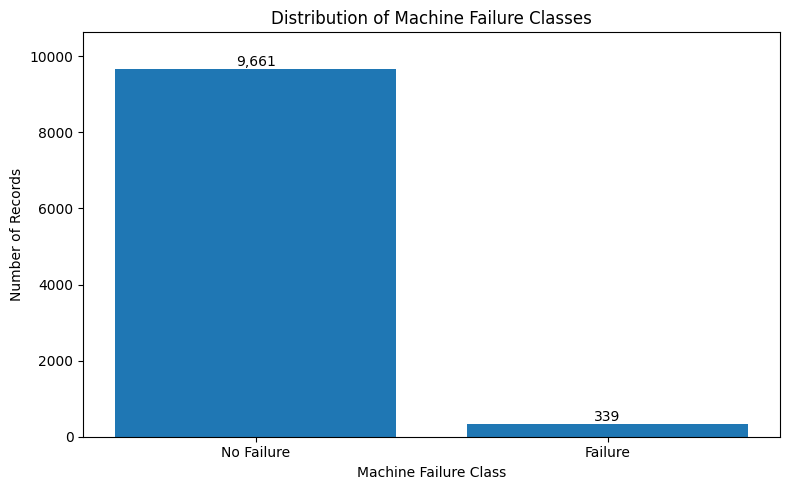

Chart saved successfully.


In [4]:
import matplotlib.pyplot as plt

# Prepare class labels and counts
class_labels = ["No Failure", "Failure"]
class_counts = [
    int((df["Machine failure"] == 0).sum()),
    int((df["Machine failure"] == 1).sum())
]

# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_labels, class_counts)

# Add exact values above each bar
for bar, count in zip(bars, class_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

ax.set_title("Distribution of Machine Failure Classes")
ax.set_xlabel("Machine Failure Class")
ax.set_ylabel("Number of Records")
ax.set_ylim(0, max(class_counts) * 1.10)

plt.tight_layout()

# Save the chart
plt.savefig(
    "../reports/figures/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/ai4i2020.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (10000, 14)


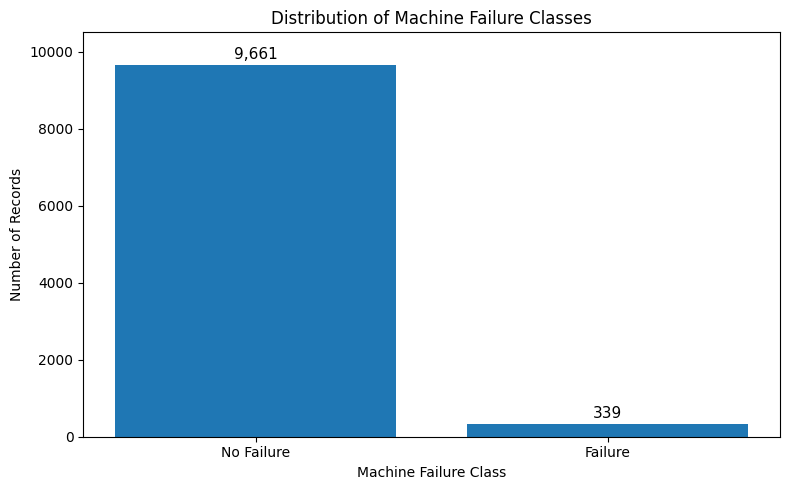

Chart saved successfully.


In [5]:
import matplotlib.pyplot as plt

class_labels = ["No Failure", "Failure"]

class_counts = [
    int((df["Machine failure"] == 0).sum()),
    int((df["Machine failure"] == 1).sum())
]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(class_labels, class_counts)

for bar, count in zip(bars, class_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title("Distribution of Machine Failure Classes")
ax.set_xlabel("Machine Failure Class")
ax.set_ylabel("Number of Records")
ax.set_ylim(0, 10500)

plt.tight_layout()

plt.savefig(
    "../reports/figures/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Observation: Failure-Class Distribution

The dataset is highly imbalanced:

- **No failure:** 9,661 records (96.61%)
- **Failure:** 339 records (3.39%)

The chart shows that failure cases are much rarer than normal cases. Therefore, accuracy alone could be misleading. During model evaluation, we should focus mainly on **recall, precision, F1 score, and PR-AUC**.

In [6]:
# Show descriptive statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


### Observation: Descriptive Statistics

The dataset contains 10,000 observations with complete numeric values.

Key findings:

- Air temperature ranges from 295.3 K to 304.5 K.
- Process temperature ranges from 305.7 K to 313.8 K.
- Rotational speed varies widely, from 1,168 rpm to 2,886 rpm.
- Torque ranges from 3.8 Nm to 76.6 Nm.
- Tool wear ranges from 0 to 253 minutes.
- The mean of `Machine failure` is 0.0339, confirming that only 3.39% of records represent failures.

The wide ranges in rotational speed, torque, and tool wear suggest that these variables may be important for identifying unusual operating conditions and machine failures.

In [ ]:
import matplotlib.pyplot as plt

sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].hist(df[col], bins=30, color="#4C72B0", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Hide the unused 6th subplot
axes[-1].axis("off")

plt.tight_layout()
plt.savefig("../reports/figures/sensor_histograms.png", dpi=150)
plt.show()

NameError: name 'df' is not defined

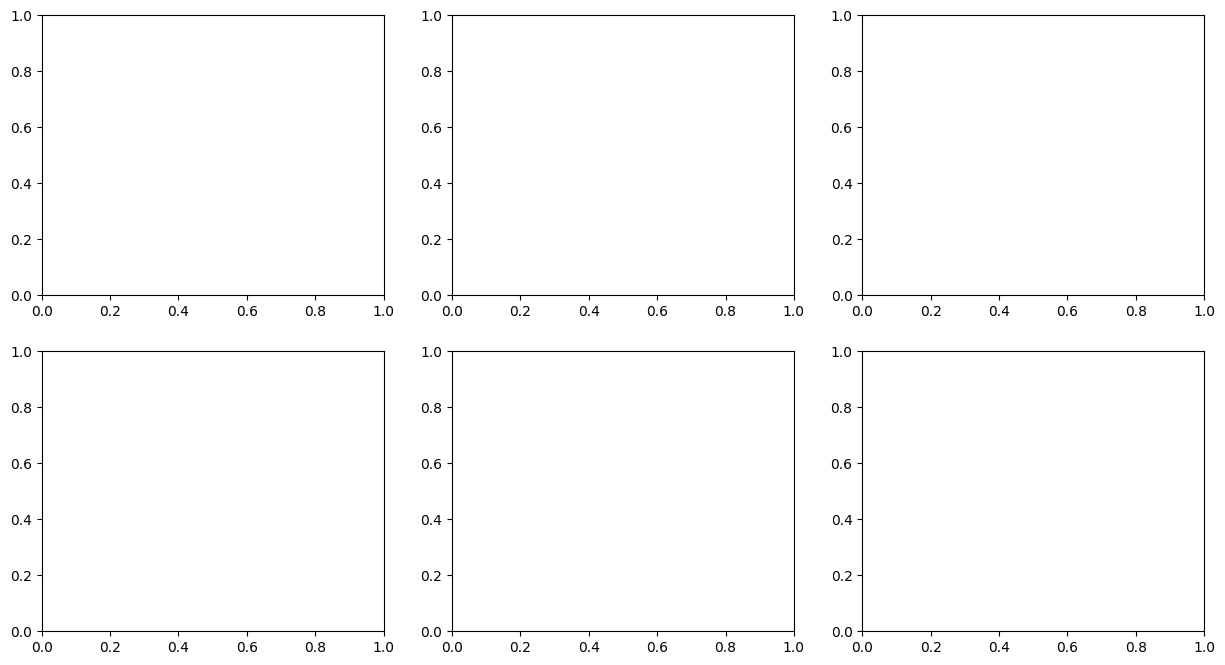

In [1]:
import matplotlib.pyplot as plt

sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].hist(df[col], bins=30, color="#4C72B0", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Hide the unused 6th subplot
axes[-1].axis("off")

plt.tight_layout()
plt.savefig("../reports/figures/sensor_histograms.png", dpi=150)
plt.show()

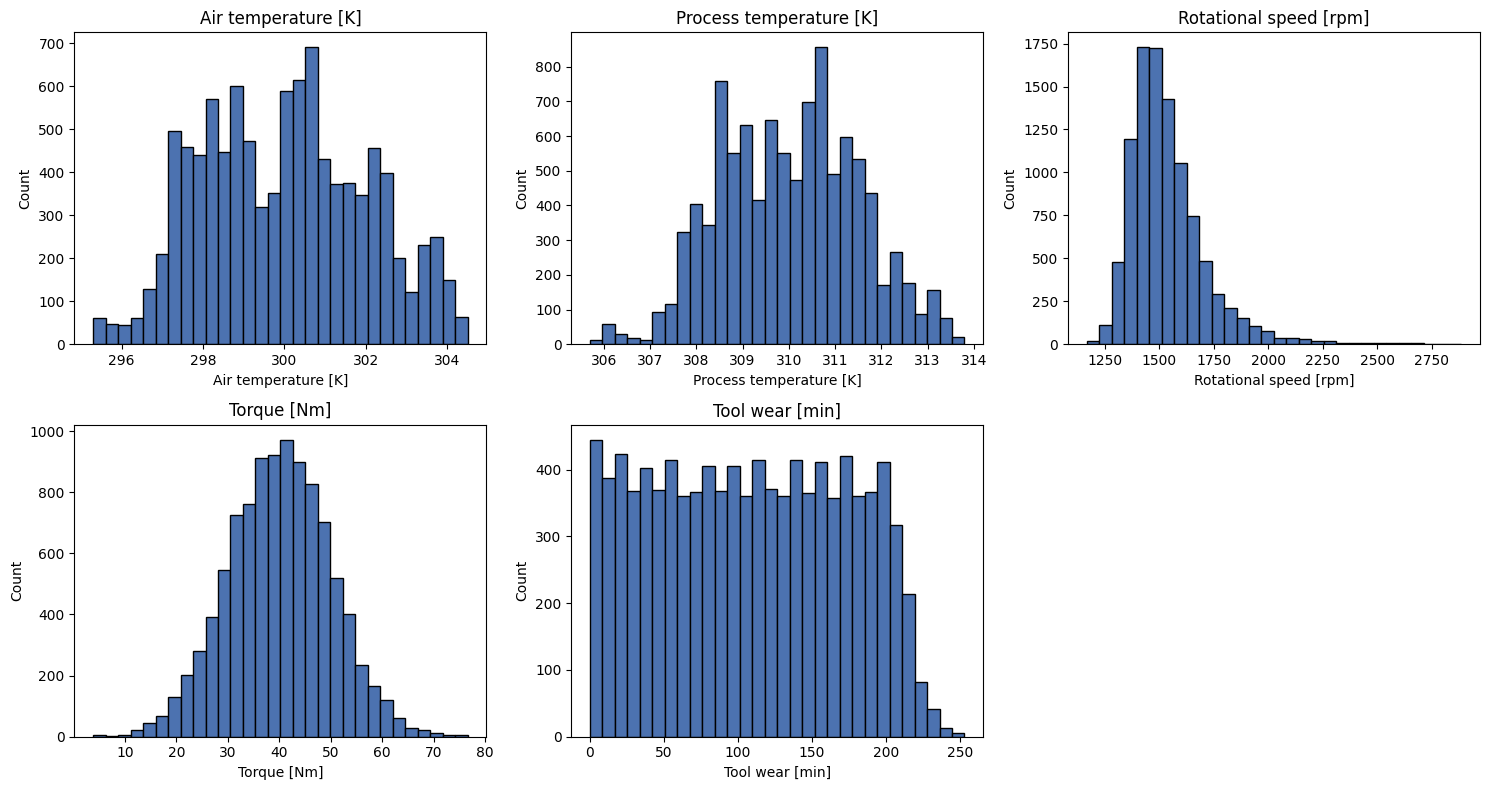

In [3]:
import matplotlib.pyplot as plt

sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].hist(df[col], bins=30, color="#4C72B0", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Hide the unused 6th subplot
axes[-1].axis("off")

plt.tight_layout()
plt.savefig("../reports/figures/sensor_histograms.png", dpi=150)
plt.show()

### Observation: Sensor Distributions

- **Air temperature** and **Process temperature** show broad, structured distributions.
- **Rotational speed** is right-skewed, with most values concentrated around 1,400–1,700 rpm and a long tail toward higher speeds.
- **Torque** is approximately bell-shaped (normal-like).
- **Tool wear** is spread fairly evenly across most of its range, then drops off near the upper end.

These shapes suggest that most sensor variables are reasonably well-behaved, though Rotational speed's skew may be worth revisiting later (e.g. when deciding on scaling methods for modelling).

In [2]:
print("Shape of df:", df.shape)
print()
print("Exact column names:")
for c in df.columns:
    print(repr(c))
print()

sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in sensor_cols:
    if col in df.columns:
        print(col, "-> dtype:", df[col].dtype, "| non-null count:", df[col].count(), "| sample values:", df[col].head(3).tolist())
    else:
        print(col, "-> NOT FOUND in df.columns")

NameError: name 'df' is not defined

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/raw/ai4i2020.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (10000, 14)


In [2]:
print("Shape of df:", df.shape)
print()
print("Exact column names:")
for c in df.columns:
    print(repr(c))
print()

sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in sensor_cols:
    if col in df.columns:
        print(col, "-> dtype:", df[col].dtype, "| non-null count:", df[col].count(), "| sample values:", df[col].head(3).tolist())
    else:
        print(col, "-> NOT FOUND in df.columns")

Shape of df: (10000, 14)

Exact column names:
'UDI'
'Product ID'
'Type'
'Air temperature [K]'
'Process temperature [K]'
'Rotational speed [rpm]'
'Torque [Nm]'
'Tool wear [min]'
'Machine failure'
'TWF'
'HDF'
'PWF'
'OSF'
'RNF'

Air temperature [K] -> dtype: float64 | non-null count: 10000 | sample values: [298.1, 298.2, 298.1]
Process temperature [K] -> dtype: float64 | non-null count: 10000 | sample values: [308.6, 308.7, 308.5]
Rotational speed [rpm] -> dtype: int64 | non-null count: 10000 | sample values: [1551, 1408, 1498]
Torque [Nm] -> dtype: float64 | non-null count: 10000 | sample values: [42.8, 46.3, 49.4]
Tool wear [min] -> dtype: int64 | non-null count: 10000 | sample values: [0, 3, 5]


In [4]:
### Observation: Sensor Distributions

- **Air temperature** and **Process temperature** show broad, structured distributions.
- **Rotational speed** is right-skewed, with most values concentrated around 1,400–1,700 rpm and a long tail toward higher speeds.
- **Torque** is approximately bell-shaped (normal-like).
- **Tool wear** is spread fairly evenly across most of its range, then drops off near the upper end.

These shapes suggest that most sensor variables are reasonably well-behaved, though Rotational speed's skew may be worth revisiting later (e.g. when deciding on scaling methods for modelling).

SyntaxError: invalid decimal literal (687543469.py, line 4)

### Observation: Sensor Distributions

The five main sensor variables show different distribution patterns:

- **Air temperature** and **process temperature** show broad, structured distributions.
- **Rotational speed** is right-skewed, with most values concentrated around 1,400–1,700 rpm and a long tail toward higher speeds.
- **Torque** is approximately bell-shaped.
- **Tool wear** is distributed across most of its range, then drops near the upper end.

The distributions are reasonably well behaved, although the skew in rotational speed may be worth considering later during modelling.

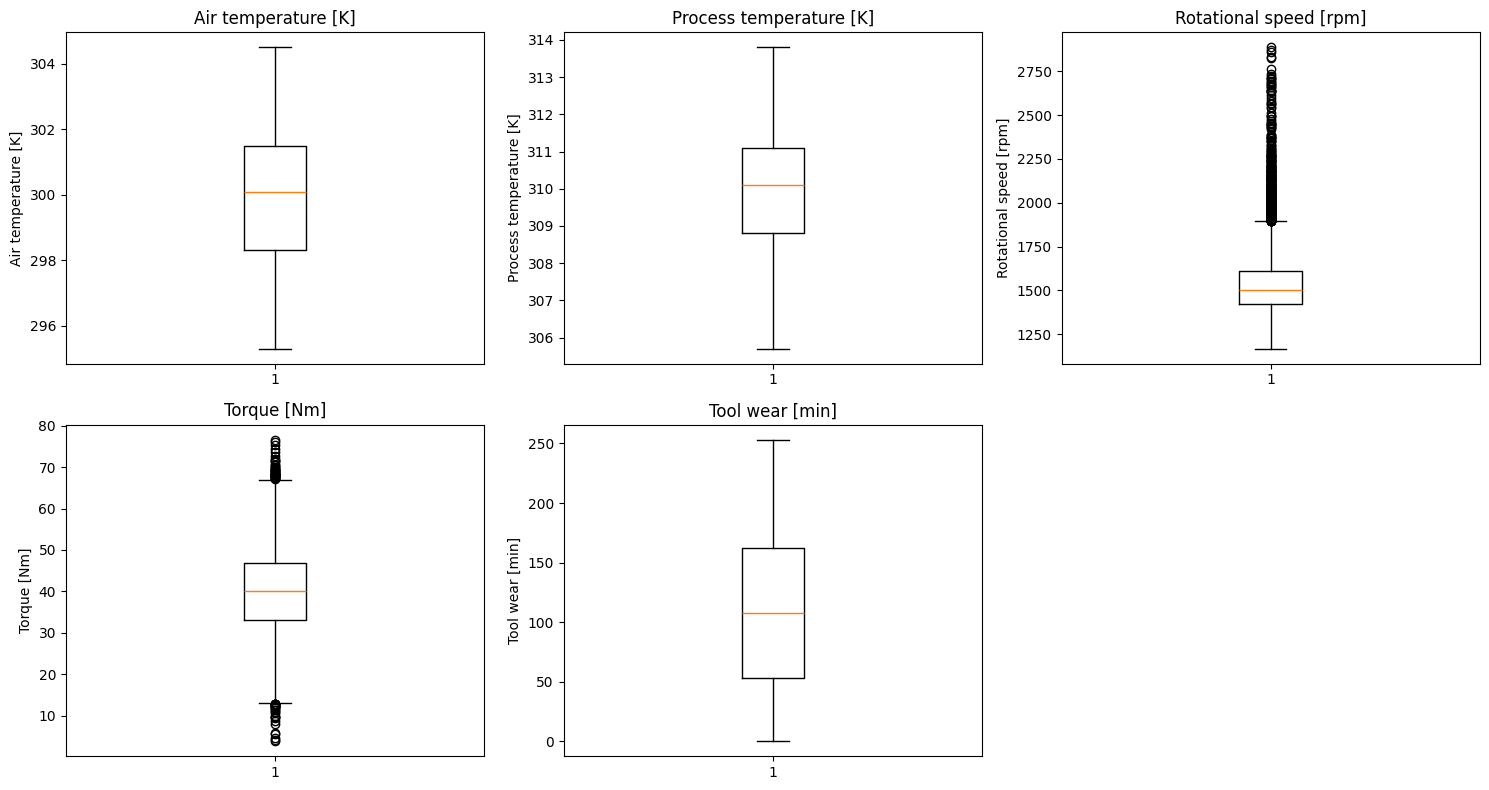

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

axes[-1].axis("off")

plt.tight_layout()
plt.savefig("../reports/figures/sensor_boxplots.png", dpi=150)
plt.show()

### Observation: Outliers in Sensor Variables

- **Air temperature** and **Process temperature**: no strong outliers visible.
- **Rotational speed**: several high-value outliers above roughly 1,900 rpm.
- **Torque**: several high-value outliers above roughly 67 Nm.
- **Tool wear**: no major outliers visible.

These outliers are not treated as data errors. In this dataset, unusually high rotational speed and torque may correspond to genuine failure-related conditions (e.g. overstrain or power failure). These points will **not** be removed automatically — they will be investigated further when we look at sensor distributions broken down by failure class.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns relevant to correlation
numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix — Sensor Variables and Machine Failure")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_matrix.png")
plt.show()

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns relevant to correlation
numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix — Sensor Variables and Machine Failure")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_matrix.png")
plt.show()

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/ai4i2020.csv")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


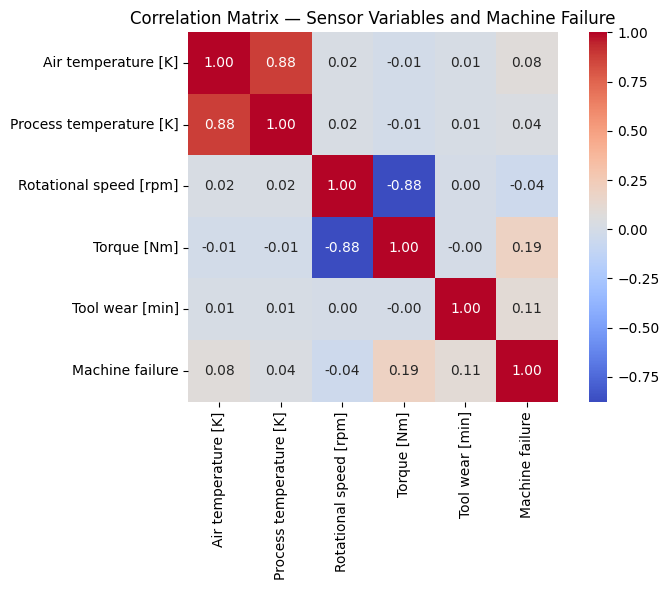

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns relevant to correlation
numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix — Sensor Variables and Machine Failure")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_matrix.png")
plt.show()

In [4]:
print(
    "Air temperature vs Process temperature:",
    corr_matrix.loc["Air temperature [K]", "Process temperature [K]"]
)

print(
    "Torque vs Rotational speed:",
    corr_matrix.loc["Torque [Nm]", "Rotational speed [rpm]"]
)

print(
    "Tool wear vs Machine failure:",
    corr_matrix.loc["Tool wear [min]", "Machine failure"]
)

print(
    "Torque vs Machine failure:",
    corr_matrix.loc["Torque [Nm]", "Machine failure"]
)

Air temperature vs Process temperature: 0.8761071581166637
Torque vs Rotational speed: -0.8750270862996037
Tool wear vs Machine failure: 0.1054482189195948
Torque vs Machine failure: 0.1913207750594941


### Correlation Matrix — Interpretation

- **Air temperature and Process temperature are strongly positively correlated (r ≈ 0.88)** — expected, since process temperature is influenced by ambient air temperature plus heat generated during operation.
- **Torque and Rotational speed are strongly negatively correlated (r ≈ -0.88)** — consistent with a roughly constant power relationship, where an increase in one tends to come with a decrease in the other.
- **Torque shows a weak-to-moderate positive correlation with Machine failure (r ≈ 0.19)** — the strongest sensor-to-failure relationship found so far, but not strong enough on its own to be a reliable predictor.
- **Tool wear shows a weak positive correlation with Machine failure (r ≈ 0.11)** — some relationship exists, but it's minor in isolation.
- No single sensor is strongly correlated with Machine failure by itself. This suggests failures likely depend on *combinations* of sensor conditions rather than any one variable — which motivates the planned feature engineering (e.g., a Power feature combining torque and rotational speed) and breaking sensor distributions down by failure class next.

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/ai4i2020.csv")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.boxplot(x='Machine failure', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} by Machine failure")
    axes[i].set_xlabel("Machine failure (0 = No, 1 = Yes)")

axes[-1].axis('off')

plt.tight_layout()
plt.savefig("../reports/figures/sensor_by_failure_class.png")
plt.show()

NameError: name 'plt' is not defined

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

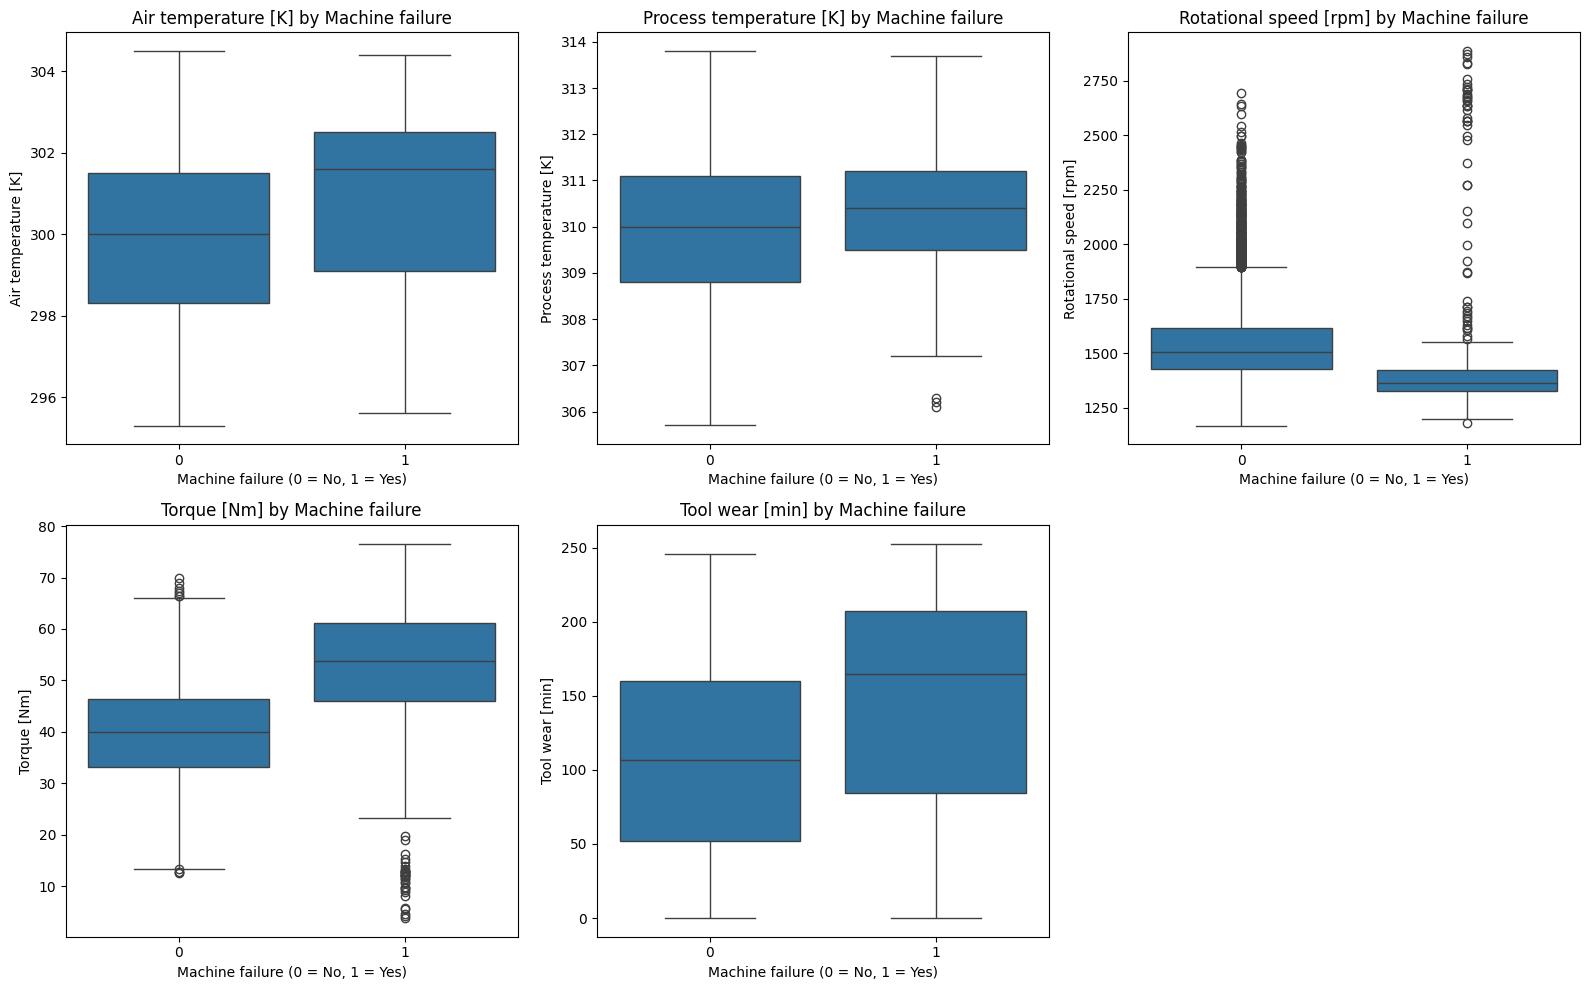

In [4]:
sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.boxplot(x='Machine failure', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} by Machine failure")
    axes[i].set_xlabel("Machine failure (0 = No, 1 = Yes)")

axes[-1].axis('off')

plt.tight_layout()
plt.savefig("../reports/figures/sensor_by_failure_class.png")
plt.show()

### Sensor Distributions by Failure Class — Interpretation

- **Air temperature**: failure records show a somewhat higher median (~301.5–302 K) than non-failure records (~300 K), though with overlap between classes.
- **Process temperature**: minimal difference between classes (~310.3 K vs ~310 K) — considerable overlap, weak separating power.
- **Rotational speed**: failure records show a *lower* median (~1,375–1,400 rpm) than non-failure records (~1,500 rpm). Both classes contain high-speed outliers, but failure records include several extreme values up to ~2,750–2,800 rpm.
- **Torque**: the clearest separation observed — failure median (~54 Nm) is notably higher than non-failure median (~40 Nm). This is a stronger distinction than the correlation coefficient alone suggested (r ≈ 0.19), showing that correlation can understate a real difference in medians.
- **Tool wear**: failure records show a higher median (~160–165 min) than non-failure records (~105 min), with a wider spread in the failure class.
- **Overall takeaway**: Torque and Tool wear appear to be the most visually separating variables between failure and non-failure machines, followed by Rotational speed and Air temperature. Process temperature shows the least separation. This motivates the planned engineered features — particularly Power (torque × rotational speed) and the Wear–torque interaction — since combining these variables may sharpen the separation further than any single sensor alone.

In [5]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# How many times each failure type occurs
failure_type_counts = df[failure_types].sum()
print("Failure type counts:")
print(failure_type_counts)
print()

# Total individual failure-type flags vs actual Machine failure count
print("Sum of all failure-type flags:", failure_type_counts.sum())
print("Actual Machine failure count:", df['Machine failure'].sum())
print()

# Check how many failure records have more than one failure type flagged at once
multi_type_failures = df[df[failure_types].sum(axis=1) > 1]
print("Records with more than one failure type flagged:", len(multi_type_failures))

Failure type counts:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Sum of all failure-type flags: 373
Actual Machine failure count: 339

Records with more than one failure type flagged: 24


### Failure-Type Analysis — Interpretation

- **Failure type counts**: HDF (Heat Dissipation Failure) is the most common individual failure type (115 records), followed by OSF (Overstrain Failure, 98), PWF (Power Failure, 95), TWF (Tool Wear Failure, 46), and RNF (Random Failure, 19 — the rarest, consistent with it representing failures unrelated to any specific mechanism).
- **Sum of all failure-type flags (373) exceeds the actual Machine failure count (339)** by 34. This is not a data error — it's explained by the 24 records where more than one failure type is flagged simultaneously (a machine can fail for more than one reason at once), which causes those records to be counted multiple times in the flag sum.
- **Implication for modeling**: since a small number of failures involve overlapping failure types, and the failure-type columns directly describe *how* a failure occurred, these columns should not be used as predictors for the "Machine failure" target — they would leak information about the outcome directly, rather than serve as legitimate input features. This confirms the leakage concern noted earlier in the project.
- **HDF being the most common type**, combined with the earlier finding that Torque and Tool wear show the clearest separation by failure class, suggests these mechanical/thermal stress factors may be worth exploring further — but confirming which sensors relate to which specific failure type would require further breakdown (not yet done) rather than assumption.

## Final EDA Summary

**Dataset**: AI4I 2020 Predictive Maintenance Dataset — a synthetic benchmark (10,000 rows, 14 columns), not real factory sensor data. No missing values, no duplicate rows.

**Target**: `Machine failure` is severely imbalanced — 9,661 no-failure records (96.61%) vs 339 failure records (3.39%). Accuracy is not a suitable evaluation metric; recall, precision, F1, and PR-AUC will be prioritized instead.

**Sensor distributions**: Air and Process temperature are broadly distributed; Rotational speed is right-skewed; Torque is roughly bell-shaped; Tool wear is spread across its range. Rotational speed and Torque contain notable high-value outliers, which were intentionally kept rather than removed, since they may represent genuine failure-related conditions.

**Correlations**: Air temperature and Process temperature are strongly correlated (r ≈ 0.88). Torque and Rotational speed are strongly negatively correlated (r ≈ -0.88), consistent with a roughly constant-power relationship. No single sensor is strongly correlated with Machine failure — Torque (r ≈ 0.19) and Tool wear (r ≈ 0.11) show the strongest, but still weak, direct relationships.

**Sensor differences by failure class**: Despite weak correlations, Torque and Tool wear show a clear difference in medians between failure and non-failure records (Torque: ~54 vs ~40 Nm; Tool wear: ~160–165 vs ~105 min) — a case where correlation understated a real, visible difference. Rotational speed is lower on average for failures but contains more extreme high-speed outliers among failures specifically. Process temperature shows the least separation of any sensor.

**Failure types**: HDF (Heat Dissipation Failure, 115 records) is the most common failure mechanism, followed by OSF (98), PWF (95), TWF (46), and RNF (19, the rarest). 24 records involve more than one failure type simultaneously, explaining why the sum of failure-type flags (373) exceeds the actual failure count (339). These failure-type columns will be excluded from future model features, since they directly describe failure outcomes rather than independent predictors.

**Key takeaway going into modeling**: No single sensor reliably predicts failure alone. Torque and Tool wear currently look like the most promising individual features, with Rotational speed potentially useful due to its outlier behavior in failure cases. This motivates the planned engineered features — particularly Power (torque × rotational speed) and a Wear–Torque interaction term — as combining variables may capture patterns that no single sensor shows on its own.

**Important limitation**: All findings above are descriptive/visual observations from EDA, not statistically tested or model-verified. The dataset is synthetic, and results should not be interpreted as validated real-world failure-prediction capability.

In [6]:
# Drop identifier columns that carry no predictive signal
df_model = df.drop(columns=['UDI', 'Product ID'])

print("Original shape:", df.shape)
print("Shape after dropping identifiers:", df_model.shape)
print()
print("Remaining columns:")
print(df_model.columns.tolist())

Original shape: (10000, 14)
Shape after dropping identifiers: (10000, 12)

Remaining columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [7]:
print(df_model['Type'].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [8]:
# One-hot encode the Type column
df_model = pd.get_dummies(df_model, columns=['Type'], prefix='Type')

print("Shape after encoding Type:", df_model.shape)
print()
print("New columns:")
print(df_model.columns.tolist())
print()
print(df_model[['Type_H', 'Type_L', 'Type_M']].head())

Shape after encoding Type: (10000, 14)

New columns:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_H', 'Type_L', 'Type_M']

   Type_H  Type_L  Type_M
0   False   False    True
1   False    True   False
2   False    True   False
3   False    True   False
4   False    True   False


In [9]:
# Leakage columns - describe HOW a failure happened, not usable as predictors
leakage_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Target
y = df_model['Machine failure']

# Features: drop target + leakage columns
X = df_model.drop(columns=['Machine failure'] + leakage_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("X columns:")
print(X.columns.tolist())
print()
print("y value counts:")
print(y.value_counts())

X shape: (10000, 8)
y shape: (10000,)

X columns:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']

y value counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

# First split: separate out the test set (e.g. 70% train+val, 15% val, 15% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Second split: separate train and validation from the remaining 85%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)
# 0.1765 of the remaining 85% ≈ 15% of the original total

print("Train shape:", X_train.shape, "| Failure rate:", y_train.mean().round(4))
print("Val shape:  ", X_val.shape,   "| Failure rate:", y_val.mean().round(4))
print("Test shape: ", X_test.shape,  "| Failure rate:", y_test.mean().round(4))

Train shape: (6999, 8) | Failure rate: 0.0339
Val shape:   (1501, 8) | Failure rate: 0.034
Test shape:  (1500, 8) | Failure rate: 0.034


### Data Preparation Summary

- Dropped identifier columns (`UDI`, `Product ID`) — no predictive value.
- One-hot encoded `Type` into `Type_H`, `Type_L`, `Type_M`.
- Separated features (`X`, 8 columns) from target (`y`, `Machine failure`).
- Excluded failure-type columns (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) from `X` to prevent target leakage.
- Created a stratified train (6,999) / validation (1,501) / test (1,500) split, preserving the ~3.39% failure rate across all three sets.
- Feature scaling was not applied at this stage, since initial models will be tree-based; it will be added later if a distance-based model (e.g. Logistic Regression) is introduced.

In [11]:
Power = Torque × Rotational Speed × 2π / 60

SyntaxError: invalid character '×' (U+00D7) (2320402865.py, line 1)

In [12]:
import numpy as np

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

for dataset in [X_train, X_val, X_test]:
    dataset['Power'] = dataset['Torque [Nm]'] * dataset['Rotational speed [rpm]'] * (2 * np.pi / 60)

print(X_train[['Torque [Nm]', 'Rotational speed [rpm]', 'Power']].head())
print()
print("Power stats (train):")
print(X_train['Power'].describe())

      Torque [Nm]  Rotational speed [rpm]        Power
5771         43.7                    1525  6978.786281
771          58.6                    1311  8045.053299
7708         32.3                    1709  5780.603786
1795         38.3                    1498  6008.128398
7887         37.9                    1590  6310.517163

Power stats (train):
count     6999.000000
mean      6280.539176
std       1068.169070
min       1148.440610
25%       5563.409778
50%       6276.713626
75%       7009.458697
max      10469.923005
Name: Power, dtype: float64


In [13]:
for dataset in [X_train, X_val, X_test]:
    dataset['Temp_diff'] = dataset['Process temperature [K]'] - dataset['Air temperature [K]']

print(X_train[['Air temperature [K]', 'Process temperature [K]', 'Temp_diff']].head())
print()
print("Temp_diff stats (train):")
print(X_train['Temp_diff'].describe())

      Air temperature [K]  Process temperature [K]  Temp_diff
5771                301.6                    311.2        9.6
771                 296.8                    308.0       11.2
7708                300.5                    311.4       10.9
1795                298.1                    307.7        9.6
7887                300.7                    312.4       11.7

Temp_diff stats (train):
count    6999.00000
mean       10.00220
std         1.00067
min         7.60000
25%         9.30000
50%         9.80000
75%        11.00000
max        12.10000
Name: Temp_diff, dtype: float64


In [14]:
for dataset in [X_train, X_val, X_test]:
    dataset['Wear_Torque'] = dataset['Tool wear [min]'] * dataset['Torque [Nm]']

print(X_train[['Tool wear [min]', 'Torque [Nm]', 'Wear_Torque']].head())
print()
print("Wear_Torque stats (train):")
print(X_train['Wear_Torque'].describe())

      Tool wear [min]  Torque [Nm]  Wear_Torque
5771               91         43.7       3976.7
771                19         58.6       1113.4
7708               64         32.3       2067.2
1795               81         38.3       3102.3
7887               98         37.9       3714.2

Wear_Torque stats (train):
count     6999.000000
mean      4310.321460
std       2815.099012
min          0.000000
25%       1963.500000
50%       3996.000000
75%       6285.600000
max      14999.500000
Name: Wear_Torque, dtype: float64


In [15]:
### Feature Engineering Summary

Three engineered features were added to `X_train`, `X_val`, and `X_test`, each computed independently on every set (no leakage risk, since these are deterministic formulas on existing columns, not values learned from data):

- **Power** = Torque × Rotational speed × (2π / 60) — converts rpm to rad/s, giving a physically meaningful Power value in Watts. Train range: ~1,148–10,470 W (mean ~6,281 W).
- **Temp_diff** = Process temperature − Air temperature — captures the gap between internal and ambient temperature, relevant given HDF (Heat Dissipation Failure) is the most common failure type. Train range: ~7.6–12.1 K (mean ~10.0 K).
- **Wear_Torque** = Tool wear × Torque — an interaction term testing whether high torque combined with high wear is a stronger signal than either alone, motivated by both variables independently showing strong separation by failure class in EDA. Train range: 0–14,999.5 (mean ~4,310).

**Important limitation**: These features are engineered from variables already flagged in EDA, not yet statistically validated as improving model performance — their actual predictive value will only be confirmed once a baseline model is trained and compared against a version with these features included.

SyntaxError: invalid character '×' (U+00D7) (357447989.py, line 5)

### Feature Engineering Summary

Three engineered features were added to `X_train`, `X_val`, and `X_test`, each computed independently on every set (no leakage risk, since these are deterministic formulas on existing columns, not values learned from data):

- **Power** = Torque × Rotational speed × (2π / 60) — converts rpm to rad/s, giving a physically meaningful Power value in Watts. Train range: ~1,148–10,470 W (mean ~6,281 W).
- **Temp_diff** = Process temperature − Air temperature — captures the gap between internal and ambient temperature, relevant given HDF (Heat Dissipation Failure) is the most common failure type. Train range: ~7.6–12.1 K (mean ~10.0 K).
- **Wear_Torque** = Tool wear × Torque — an interaction term testing whether high torque combined with high wear is a stronger signal than either alone, motivated by both variables independently showing strong separation by failure class in EDA. Train range: 0–14,999.5 (mean ~4,310).

**Important limitation**: These features are engineered from variables already flagged in EDA, not yet statistically validated as improving model performance — their actual predictive value will only be confirmed once a baseline model is trained and compared against a version with these features included.

In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Majority-class baseline: always predicts the most frequent class
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)

y_val_pred = baseline.predict(X_val)

print("Baseline accuracy:", accuracy_score(y_val, y_val_pred))
print()
print("Confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))
print()
print("Classification report:")
print(classification_report(y_val, y_val_pred))

Baseline accuracy: 0.966022651565623

Confusion matrix:
[[1450    0]
 [  51    0]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1450
           1       0.00      0.00      0.00        51

    accuracy                           0.97      1501
   macro avg       0.48      0.50      0.49      1501
weighted avg       0.93      0.97      0.95      1501



/home/merin/projects/predictive_maintenance/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/merin/projects/predictive_maintenance/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/merin/projects/predictive_maintenance/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

### Baseline Model — Interpretation

The majority-class baseline achieves 96.60% accuracy simply by always predicting "no failure" — matching the original class distribution. However, the confusion matrix shows it correctly identifies 0 out of 51 actual failures in the validation set (recall = 0.00 for class 1). This concretely demonstrates why accuracy alone is a misleading metric for this problem: a model can score extremely high on accuracy while being completely useless at its actual job — detecting failures. Any real model must be evaluated primarily on recall, precision, and F1 for the failure class (1), not overall accuracy, and must meaningfully beat this baseline's 0.00 recall to be considered useful.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression needs scaled features (unlike tree-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

y_val_pred_logreg = logreg.predict(X_val_scaled)

print("Logistic Regression accuracy:", accuracy_score(y_val, y_val_pred_logreg))
print()
print("Confusion matrix:")
print(confusion_matrix(y_val, y_val_pred_logreg))
print()
print("Classification report:")
print(classification_report(y_val, y_val_pred_logreg, zero_division=0))

Logistic Regression accuracy: 0.9686875416389074

Confusion matrix:
[[1443    7]
 [  40   11]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1450
           1       0.61      0.22      0.32        51

    accuracy                           0.97      1501
   macro avg       0.79      0.61      0.65      1501
weighted avg       0.96      0.97      0.96      1501



### Logistic Regression — Interpretation

Logistic Regression achieves 96.87% accuracy — barely above the baseline's 96.60% — but the meaningful difference is in the confusion matrix: it correctly identifies 11 of 51 actual failures (recall = 0.22), compared to the baseline's 0. Precision for the failure class is 0.61 (11 of 18 predicted failures were correct), and F1 is 0.32. This is a real improvement over the baseline, but still misses roughly 4 out of every 5 actual failures — not yet good enough for a practical failure-detection system. This motivates trying models better suited to imbalanced data next: a class-weighted Random Forest, and later, resampling techniques like SMOTE.

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)  # note: unscaled X_train, not X_train_scaled

y_val_pred_rf = rf.predict(X_val)

print("Random Forest accuracy:", accuracy_score(y_val, y_val_pred_rf))
print()
print("Confusion matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))
print()
print("Classification report:")
print(classification_report(y_val, y_val_pred_rf, zero_division=0))

Random Forest accuracy: 0.9906728847435043

Confusion matrix:
[[1450    0]
 [  14   37]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1450
           1       1.00      0.73      0.84        51

    accuracy                           0.99      1501
   macro avg       1.00      0.86      0.92      1501
weighted avg       0.99      0.99      0.99      1501



### Random Forest (Class-Weighted) — Interpretation

Random Forest with `class_weight='balanced'` achieves 99.07% accuracy, but more importantly, correctly identifies 37 of 51 actual failures (recall = 0.73) with perfect precision (1.00) — meaning every failure it predicted was a genuine failure, with zero false alarms. This is a substantial improvement over both the baseline (recall 0.00) and Logistic Regression (recall 0.22). 14 failures are still missed (false negatives), which remains the key area for improvement. Given tree-based models don't require feature scaling and generally tolerate the outliers identified in EDA well, this result aligns with the reasoning laid out earlier in the project. Next steps to try improving further: threshold tuning (the default 0.5 cutoff may not be optimal for recall), SMOTE for additional resampling, and XGBoost as a comparison model.

In [19]:
# Get predicted probabilities instead of hard 0/1 predictions
y_val_proba_rf = rf.predict_proba(X_val)[:, 1]

# Try a few different thresholds
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_val_pred_thresh = (y_val_proba_rf >= threshold).astype(int)
    print(f"--- Threshold: {threshold} ---")
    print(confusion_matrix(y_val, y_val_pred_thresh))
    print(classification_report(y_val, y_val_pred_thresh, zero_division=0))
    print()

--- Threshold: 0.5 ---
[[1450    0]
 [  14   37]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1450
           1       1.00      0.73      0.84        51

    accuracy                           0.99      1501
   macro avg       1.00      0.86      0.92      1501
weighted avg       0.99      0.99      0.99      1501


--- Threshold: 0.4 ---
[[1448    2]
 [  11   40]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1450
           1       0.95      0.78      0.86        51

    accuracy                           0.99      1501
   macro avg       0.97      0.89      0.93      1501
weighted avg       0.99      0.99      0.99      1501


--- Threshold: 0.3 ---
[[1444    6]
 [  11   40]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1450
           1       0.87      0.78      0.82        51

    accuracy                  

In [20]:
threshold = 0.3
y_val_pred_thresh = (y_val_proba_rf >= threshold).astype(int)
print(confusion_matrix(y_val, y_val_pred_thresh))
print(classification_report(y_val, y_val_pred_thresh, zero_division=0))

[[1444    6]
 [  11   40]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1450
           1       0.87      0.78      0.82        51

    accuracy                           0.99      1501
   macro avg       0.93      0.89      0.91      1501
weighted avg       0.99      0.99      0.99      1501



In [21]:
threshold = 0.2
y_val_pred_thresh = (y_val_proba_rf >= threshold).astype(int)
print(confusion_matrix(y_val, y_val_pred_thresh))
print(classification_report(y_val, y_val_pred_thresh, zero_division=0))

[[1439   11]
 [  11   40]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1450
           1       0.78      0.78      0.78        51

    accuracy                           0.99      1501
   macro avg       0.89      0.89      0.89      1501
weighted avg       0.99      0.99      0.99      1501



In [22]:
threshold = 0.1
y_val_pred_thresh = (y_val_proba_rf >= threshold).astype(int)
print(confusion_matrix(y_val, y_val_pred_thresh))
print(classification_report(y_val, y_val_pred_thresh, zero_division=0))

[[1411   39]
 [  10   41]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1450
           1       0.51      0.80      0.63        51

    accuracy                           0.97      1501
   macro avg       0.75      0.89      0.80      1501
weighted avg       0.98      0.97      0.97      1501



### Threshold Tuning — Interpretation

Testing thresholds 0.5, 0.3, 0.2, and 0.1 on the Random Forest's predicted probabilities showed:

| Threshold | Recall (failure) | False alarms | Precision | F1 |
|---|---|---|---|---|
| 0.5 (default) | 0.73 (37/51) | 0 | 1.00 | 0.84 |
| 0.3 | 0.78 (40/51) | 6 | 0.87 | 0.82 |
| 0.2 | 0.78 (40/51) | 11 | 0.78 | 0.78 |
| 0.1 | 0.80 (41/51) | 39 | 0.51 | 0.63 |

**Threshold 0.3 is the best balance found**: it catches 3 more failures than the default (40 vs 37) while keeping false alarms low (6) and precision reasonably high (0.87). Threshold 0.2 offers no advantage over 0.3 — identical recall, more false alarms. Threshold 0.1 gains only 1 additional failure caught over 0.3, at the cost of nearly 7x more false alarms — not a worthwhile trade for this use case.

**Decision**: threshold 0.3 will be used as the default decision boundary for this model going forward, rather than scikit-learn's default of 0.5.

**Limitation**: this threshold was chosen by inspection on the validation set. It has not yet been validated against the held-out test set, and a more rigorous approach (e.g. optimizing F1 or a cost-weighted metric across a finer grid of thresholds) could be explored later.